# 5 — Retrieval: searching a stained archive with an unstained slide

You have H&E for a new case and a library of patches that were
actually multiplex-stained. Virtual staining of the query lets you search that library in marker
space.

```
query    = Eva( QUEST virtual MIF of an H&E patch )
gallery  = Eva( real MIF ) of every patch from a different region
retrieve = embedding cosine
score    = does the retrieved patch have the query's cell composition?
```

Data: **stanford-pc** (`data/stanford-pc`, pancreas patches) — see [Tutorial 0](./00_data.ipynb).

In [1]:
import _common 
import numpy as np
import matplotlib.pyplot as plt

from quest import QuestGenerator
from questkit import cohort, retrieval

MODELS = ["quest-semantic", "quest-id", "quest-eva"]
DISP = {"quest-semantic": "QUEST-semantic", "quest-id": "QUEST-ID", "quest-eva": "QUEST-Eva"}

recs, cell_types = retrieval.cohort_records()
emb = retrieval.EvaEmbedder(device=_common.DEVICE)
panels = [retrieval.eva_panel(r, emb) for r in recs]
patches = [cohort.load_patch(r) for r in recs]

print(f"{len(recs)} patches over {len({r['region_id'] for r in recs})} regions")
print(f"per-patch panel: {min(map(len, panels))}-{max(map(len, panels))} markers, "
      f"each embedded on its own")
print(f"{len(cell_types)} cell types: {cell_types}")

326 patches over 29 regions
per-patch panel: 42-52 markers, each embedded on its own
12 cell types: ['Fibroblasts', 'Epithelial cells', 'Macrophages', 'Cytotoxic T cells', 'Lymphatic Endothelial cells', 'Helper T cells', 'Tregs', 'Other', 'Neutrophils', 'B cells', 'Plasma cells', 'Dendritic cells']


In [2]:
gallery = np.stack([emb(np.stack([p.marker(m) for m in mk]), mk)
                    for p, mk in zip(patches, panels)])
print("gallery embeddings", gallery.shape)

comp = np.stack([r["cell"] for r in recs])
major = [r["major"] for r in recs]
region = [r["region_id"] for r in recs]

gallery embeddings (326, 768)


## The three models

Each model stains every patch on that patch's own panel, the virtual stack goes through the same
**Eva** encoder, and the cosine against the gallery ranks it. Nothing else differs between the three
rows below.

Both metrics are reported against a random floor. The floor is a uniformly drawn valid gallery patch.

In [3]:
res = {}
for name in MODELS:
    gen = QuestGenerator(name, device=_common.DEVICE)
    query = np.stack([emb(gen(p.he[None], mk)[0], mk) for p, mk in zip(patches, panels)])
    res[name] = retrieval.retrieval_metrics(query @ gallery.T, comp, major, region)
    res[name]["query"] = query
    del gen

m0 = res[MODELS[0]]
print(f"{'':16}{'cell PCC@1':>12}{'major type@1':>14}")
for name in MODELS:
    r = res[name]
    print(f"{DISP[name]:16}{r['pcc@1']:>12.3f}{r['major@1']:>14.3f}")
print(f"{'random':16}{m0['random_pcc']:>12.3f}{m0['major_chance']:>14.3f}")

                  cell PCC@1  major type@1
QUEST-semantic         0.511         0.414
QUEST-ID               0.495         0.393
QUEST-Eva              0.428         0.350
random                 0.217         0.156


## Retrieval case

The virtual staining results and top-1 retrieved patch is shown.

query: Epithelial cells 81% of its cells


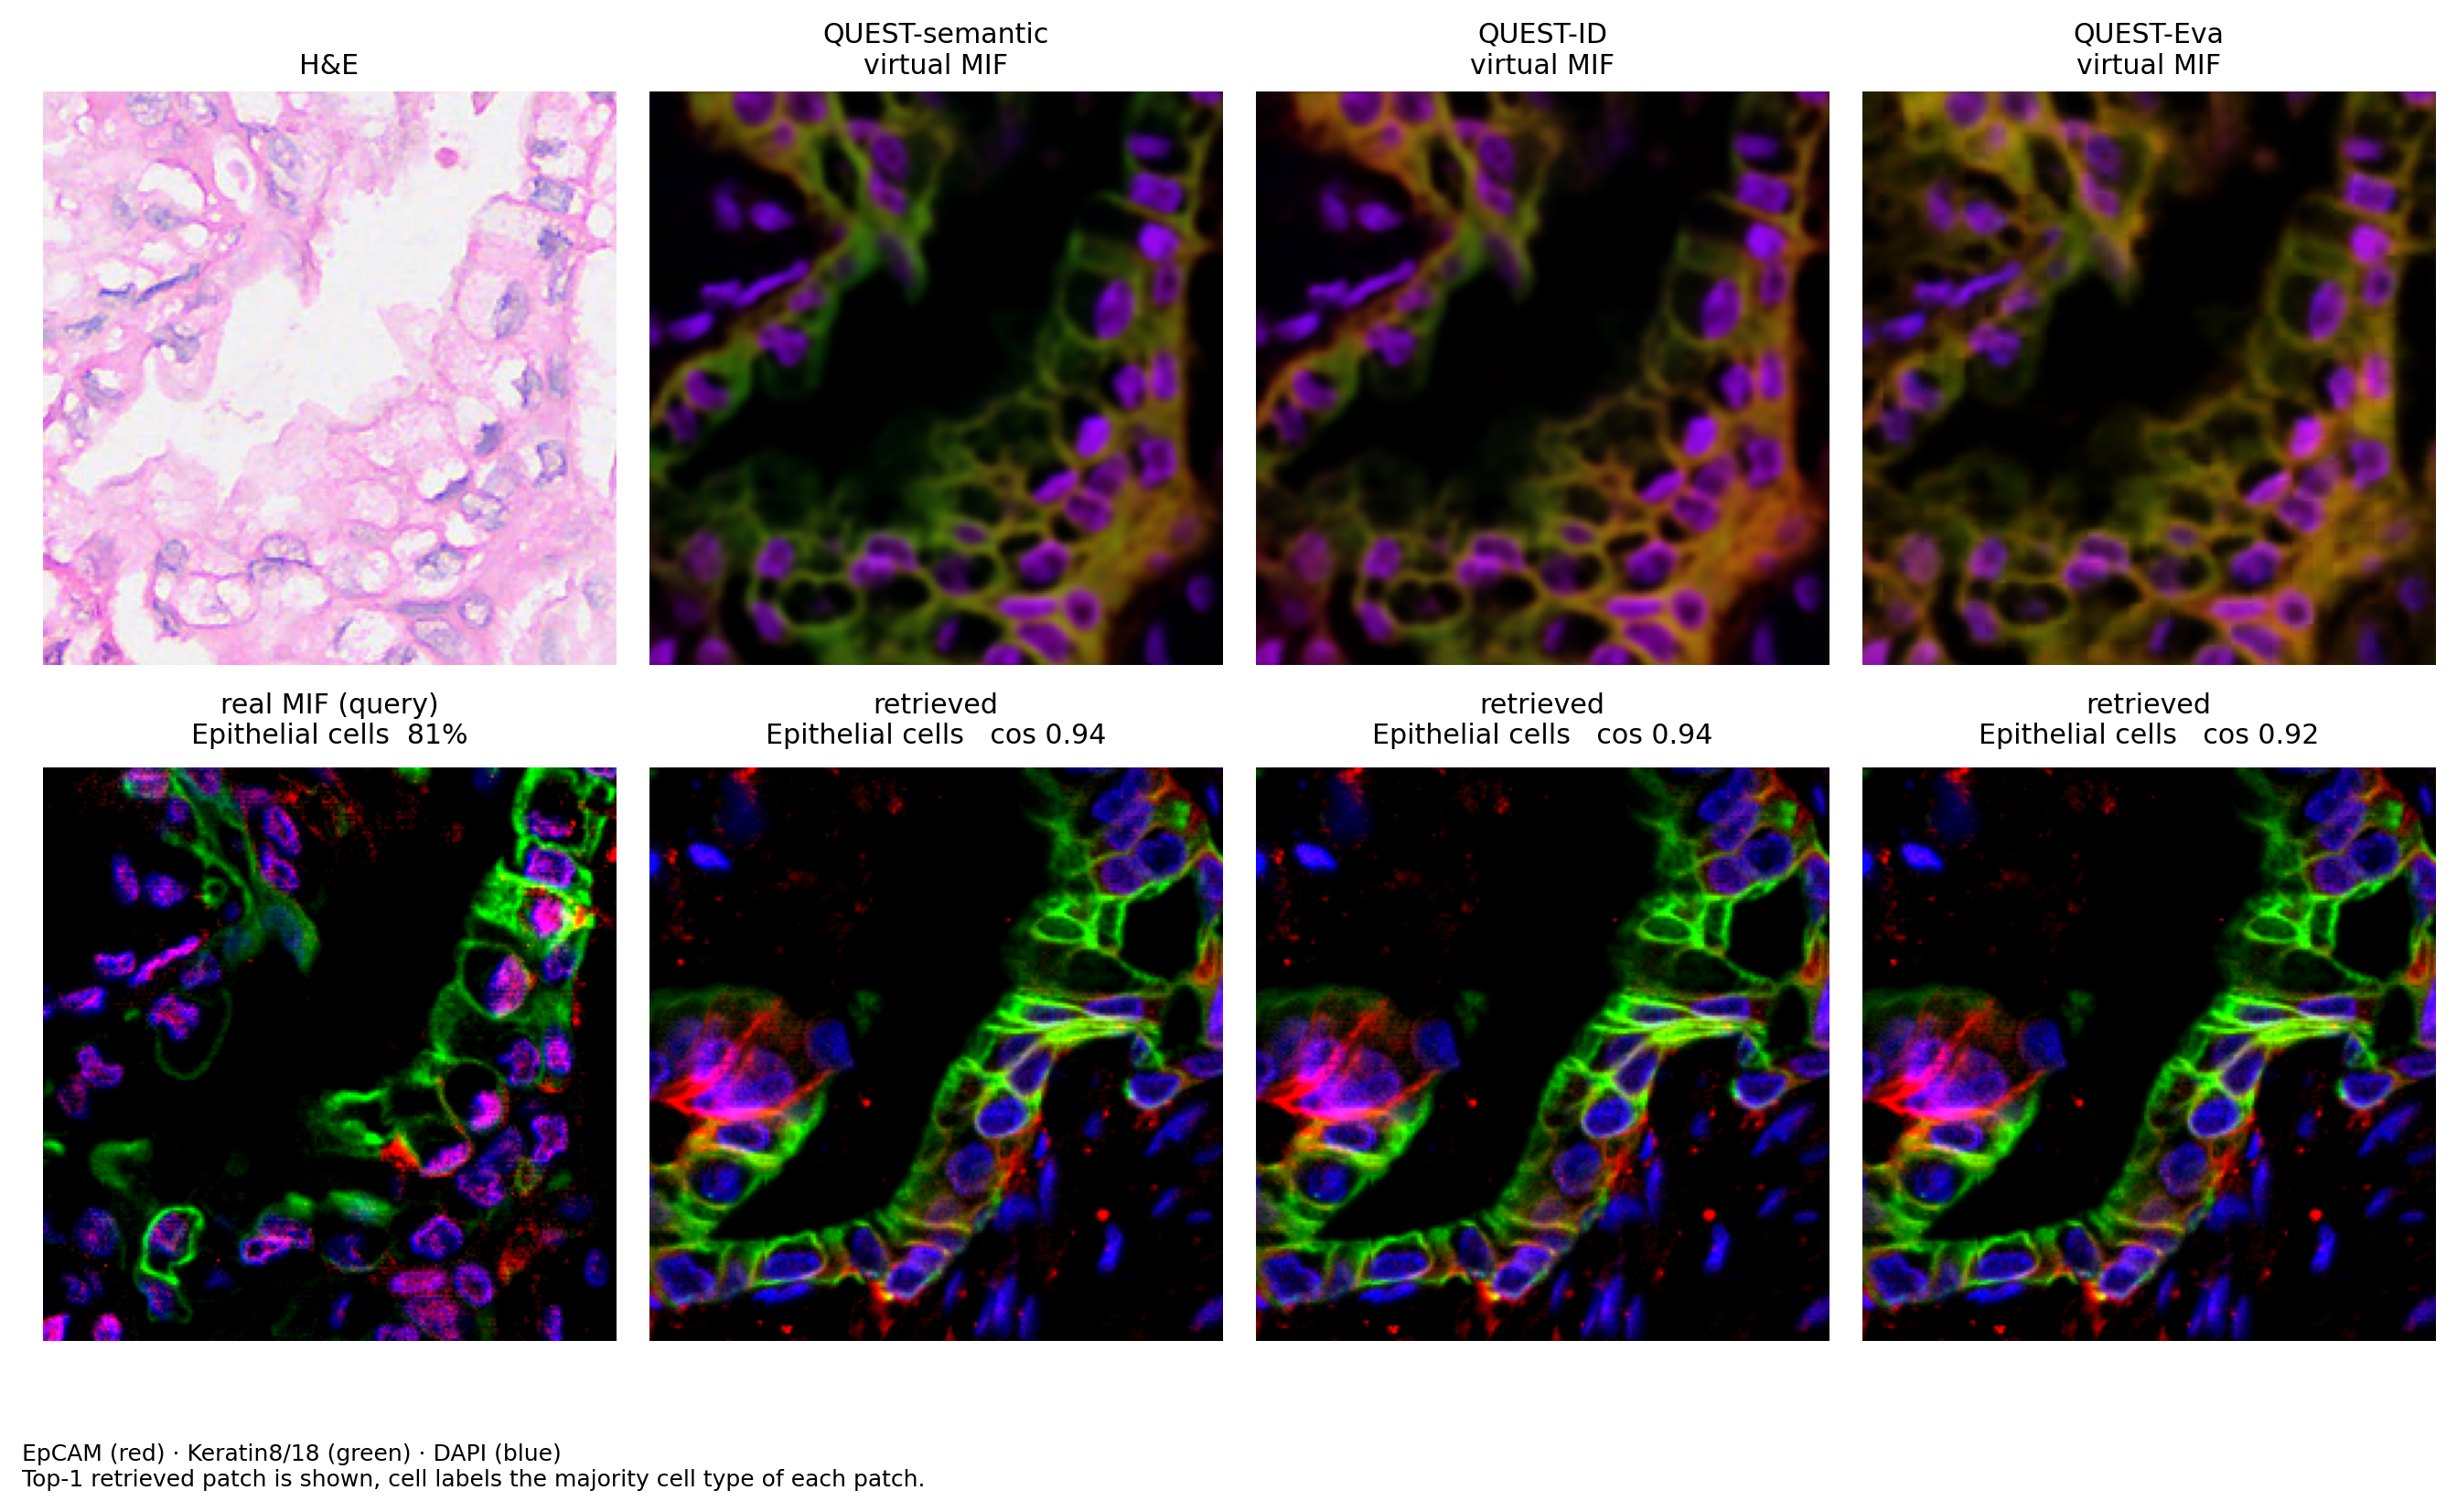

In [4]:
WANT = ["EpCAM", "Keratin8/18", "DAPI"]  # R, G, B
reg = np.asarray(region)
valid = reg[:, None] != reg[None, :]

tops = {n: np.argmax(np.where(valid, res[n]["query"] @ gallery.T, -np.inf), 1) for n in MODELS}
maj = np.asarray(major)
ok = [i for i, r in enumerate(recs)
      if r["major"] == "Epithelial cells" and set(WANT) <= set(r["biomarkers"])
      and all(maj[tops[n][i]] == "Epithelial cells" for n in MODELS)]
qi = max(ok, key=lambda i: recs[i]["cell"].max())
print(f"query: {recs[qi]['major']} {recs[qi]['cell'].max():.0%} of its cells")

real_q = np.stack([patches[qi].marker(m) for m in panels[qi]])
img_q, rng = retrieval.composite(real_q, panels[qi], WANT)

fig, ax = plt.subplots(2, 4, figsize=(11.2, 6.8))
ax[0, 0].imshow(patches[qi].he)
ax[0, 0].set_title(f"H&E", fontsize=9)
ax[1, 0].imshow(img_q)
ax[1, 0].set_title(f"real MIF (query)\n{recs[qi]['major']}  {recs[qi]['cell'].max():.0%}",
                   fontsize=9, pad=8)
for j, name in enumerate(MODELS):
    gen = QuestGenerator(name, device=_common.DEVICE)
    virt = gen(patches[qi].he[None], panels[qi])[0]
    del gen
    ax[0, j + 1].imshow(retrieval.composite(virt, panels[qi], WANT, ranges=rng)[0])
    ax[0, j + 1].set_title(f"{DISP[name]}\nvirtual MIF", fontsize=9)

    h = int(tops[name][qi])
    hit = np.stack([patches[h].marker(m) for m in panels[h]])
    cos = float(res[name]["query"][qi] @ gallery[h])
    ax[1, j + 1].imshow(retrieval.composite(hit, panels[h], WANT)[0])
    ax[1, j + 1].set_title(f"retrieved\n{recs[h]['major']}   cos {cos:.2f}",
                           fontsize=9, pad=8)
for a in ax.ravel():
    a.set_xticks([]); a.set_yticks([])
    for s in a.spines.values():
        s.set_visible(False)
fig.text(0.005, 0.012,
         "EpCAM (red) · Keratin8/18 (green) · DAPI (blue)\n"
         "Top-1 retrieved patch is shown, cell labels the majority cell type of each patch.",
         fontsize=7.5)
fig.tight_layout(rect=[0, 0.07, 1, 1], h_pad=2.4)
plt.show()